Tyler Fields

CSCI 4650

Reality Check #2: The Euler-Bernoulli Beam

#1.

**( handwritten or typed )**

Prove the second-order formula for the third derivative
$$ f''''(x) = \frac{f(x-2h)  - 4 f(x-h) +6f(x)-4f(x+h)+f(x+2h)}{h^4}+O(h^2).$$
(This is Exercise EX.5.1.21 in Sauer.)

---

$$f(x+kh) = f(x) + khf'(x) + \frac{k^2h^2}{2}f''(x) + \frac{k^3h^3}{6}f'''(x) + \frac{k^4h^4}{24}f''''(x) + \frac{k^5h^5}{120}f^{(5)}(x) + \frac{k^6h^6}{720}f^{(6)}(c_k)$$

$$f(x-2h) = f(x) -2hf'(x) + 2h^2f''(x) - \frac{4h^3}{3}f'''(x) + \frac{2h^4}{3}f''''(x) - \frac{4h^5}{15}f^{(5)}(x) + \frac{64h^6}{720}f^{(6)}(c_{-2})$$

$$f(x-h) = f(x) -hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f''''(x) - \frac{h^5}{120}f^{(5)}(x) + \frac{h^6}{720}f^{(6)}(c_{-1})$$

$$f(x+h) = f(x) +hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f''''(x) + \frac{h^5}{120}f^{(5)}(x) + \frac{h^6}{720}f^{(6)}(c_1)$$

$$f(x-2h) = f(x) +2hf'(x) + 2h^2f''(x) + \frac{4h^3}{3}f'''(x) + \frac{2h^4}{3}f''''(x) + \frac{4h^5}{15}f^{(5)}(x) + \frac{64h^6}{720}f^{(6)}(c_2)$$

---

$$f(x-2h) - 4f(x-h) + 6f(x) - 4f(x+h) + f(x+2h) = h^4f''''(x) - h^6R(h)$$

$$R(h) = \frac{1}{720}[64f^{(6)}(c_{-2})-4f^{(6)}(c_{-1})-4f^{(6)}(c_1)+64f^{(6)}(c_2)$$

$$|R(h)| \le \frac{1}{720}(64+4+4+64)M = \frac{17}{90}M$$

---

$$\frac {f(x-2h) - 4f(x-h) + 6f(x) - 4f(x+h) + f(x+2h)}{h^4} = f''''(x) - h^2R(h)$$

$$f''''(x) = \frac {f(x-2h) - 4f(x-h) + 6f(x) - 4f(x+h) + f(x+2h)}{h^4} - h^2R(h)$$

$$f''''(x) = \frac {f(x-2h) - 4f(x-h) + 6f(x) - 4f(x+h) + f(x+2h)}{h^4} + O(h^2)$$

#2.

**( colab )**

Write a python program to define the structure matrix $A$ in Equation (2.34). Then, using the **np.linalg.solve** command or code of your own design, solve the system for the displacements $y_i$ using $n=10$ grid steps. Plot the solution against the correct solution $$y(x) = \frac{f}{24EI}x^2(x^2-4Lx+6L^2),$$ where $f=f(x)$ is the constant defined above. Check the error at the end of the beam, $x = L$ meters. In this simple case the derivative approximations are exact, so your error should be near machine roundoff.

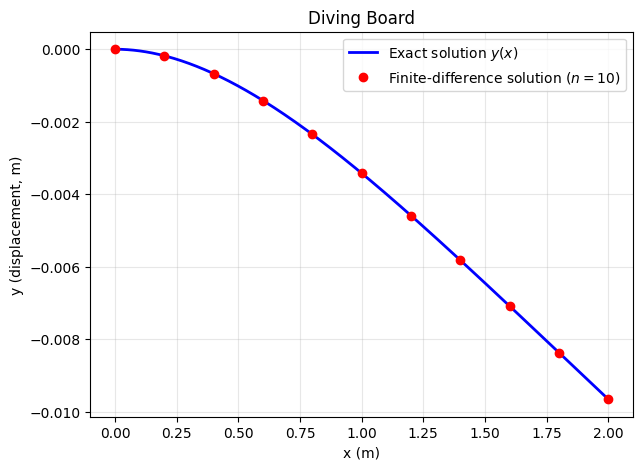



I  = 6.750000e-07 m^4
EI = 8.775000e+03 N*m^2
f0 = -42.379200 N/m
h  = 0.2

Numerical y(L) = -9.6590769230754502e-03
Exact     y(L) = -9.6590769230769265e-03
Absolute error at x=L: 1.476e-15
Relative error at x=L: 1.528e-13

Error at every grid point (numerical - exact):
[2.22803546e-17 8.55435514e-17 1.84314369e-16 3.12683907e-16
 4.66640615e-16 6.45317133e-16 8.39606162e-16 1.04517089e-15
 1.25767452e-15 1.47624968e-15]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L   = 2.0
w   = 0.30
d   = 0.03
rho = 480.0
E   = 1.3e10
g   = 9.81

I  = w * d**3 / 12.0
EI = E * I
f0 = -rho * w * d * g          # constant load f(x) = f0

n = 10
h = L / n

def f(x):
    return np.full_like(np.atleast_1d(x), f0, dtype=float)

# Structure matrix A  (Equation 2.34)
A = np.zeros((n, n))

# Row 1 (Eq. 2.31)
A[0, 0] = 16
A[0, 1] = -9
A[0, 2] = 8.0/3.0
A[0, 3] = -1.0/4.0

# Row 2: y_0 = 0
A[1, 0] = -4
A[1, 1] = 6
A[1, 2] = -4
A[1, 3] = 1

# Interior rows 3 .. n-2
for i in range(2, n - 2):
    A[i, i-2] = 1
    A[i, i-1] = -4
    A[i, i]   = 6
    A[i, i+1] = -4
    A[i, i+2] = 1

# Row n-1 (Eq. 2.32)
A[n-2, n-4] = 16.0/17.0
A[n-2, n-3] = -60.0/17.0
A[n-2, n-2] = 72.0/17.0
A[n-2, n-1] = -28.0/17.0

# Row n (Eq. 2.33)
A[n-1, n-4] = -12.0/17.0
A[n-1, n-3] = 96.0/17.0
A[n-1, n-2] = -156.0/17.0
A[n-1, n-1] = 72.0/17.0

# Right-hand side
x = np.array([i * h for i in range(1, n + 1)])   # x_1, ..., x_n
b = h**4 * f(x) / EI

# Solve Ay = b
y = np.linalg.solve(A, b)

x_full = np.concatenate(([0.0], x))
y_full = np.concatenate(([0.0], y))


# Closed-form exact solution
def y_exact(x):
    return f0 / (24 * EI) * x**2 * (x**2 - 4*L*x + 6*L**2)

x_fine = np.linspace(0, L, 400)
y_fine = y_exact(x_fine)


# Plot
plt.figure(figsize=(7, 5))
plt.plot(x_fine, y_fine, 'b-', linewidth=2, label='Exact solution $y(x)$')
plt.plot(x_full, y_full, 'ro', markersize=6, label=f'Finite-difference solution ($n={n}$)')
plt.xlabel('x (m)')
plt.ylabel('y (displacement, m)')
plt.title('Diving Board')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("\n")

# Error at x = L
y_L_numeric = y_full[-1]
y_L_exact   = y_exact(L)
error = abs(y_L_numeric - y_L_exact)

print(f"I  = {I:.6e} m^4")
print(f"EI = {EI:.6e} N*m^2")
print(f"f0 = {f0:.6f} N/m")
print(f"h  = {h}")
print()
print(f"Numerical y(L) = {y_L_numeric:.16e}")
print(f"Exact     y(L) = {y_L_exact:.16e}")
print(f"Absolute error at x=L: {error:.3e}")
print(f"Relative error at x=L: {error/abs(y_L_exact):.3e}")
print()
print("Error at every grid point (numerical - exact):")
print(y - y_exact(x))

#3.

**( colab )**

Rerun the calculation in Step 1 for $n = 10 \cdot 2^k$, where $k=1, \ldots, 8$. Make a table of the errors at $x=L$ for each $n$. Add a column to your table with the condition number of $A$ as a function of $n$.

In [ ]:
import numpy as np

L   = 2.0
w   = 0.30
d   = 0.03
rho = 480.0
E   = 1.3e10
g   = 9.81

I  = w * d**3 / 12.0
EI = E * I
f0 = -rho * w * d * g          # constant load f(x) = f0

def y_exact(x):
    return f0 / (24 * EI) * x**2 * (x**2 - 4*L*x + 6*L**2)

def build_matrix(n):
    A = np.zeros((n, n))

    # Row 1 (Eq. 2.31)
    A[0, 0] = 16
    A[0, 1] = -9
    A[0, 2] = 8.0/3.0
    A[0, 3] = -1.0/4.0

    # Row 2: y_0 = 0 already substituted in
    A[1, 0] = -4
    A[1, 1] = 6
    A[1, 2] = -4
    A[1, 3] = 1

    # Interior rows 3 ... n-2
    for i in range(2, n - 2):
        A[i, i-2] = 1
        A[i, i-1] = -4
        A[i, i]   = 6
        A[i, i+1] = -4
        A[i, i+2] = 1

    # Row n-1 (Eq. 2.32)
    A[n-2, n-4] = 16.0/17.0
    A[n-2, n-3] = -60.0/17.0
    A[n-2, n-2] = 72.0/17.0
    A[n-2, n-1] = -28.0/17.0

    # Row n (Eq. 2.33)
    A[n-1, n-4] = -12.0/17.0
    A[n-1, n-3] = 96.0/17.0
    A[n-1, n-2] = -156.0/17.0
    A[n-1, n-1] = 72.0/17.0

    return A

def solve_beam(n):
    h = L / n
    A = build_matrix(n)
    x = np.array([i * h for i in range(1, n + 1)])
    b = np.full(n, h**4 * f0 / EI)   # f is constant here

    y = np.linalg.solve(A, b)

    y_L_numeric = y[-1]
    y_L_exact   = y_exact(L)
    error_at_L  = abs(y_L_numeric - y_L_exact)

    cond_A = np.linalg.cond(A)

    return y, error_at_L, cond_A

# Loop over n = 10 * 2^k for k = 1, ..., 8
ks = range(1, 9)
ns = [10 * 2**k for k in ks]

results = []
for n in ns:
    _, err, cond_A = solve_beam(n)
    results.append((n, err, cond_A))


# Table
print(f"{'n':>8} | {'Error at x=L':>16} | {'cond(A)':>16}")
print("-" * 46)
for n, err, cond_A in results:
    print(f"{n:>8} | {err:16.6e} | {cond_A:16.6e}")


       n |     Error at x=L |          cond(A)
----------------------------------------------
      20 |     1.023487e-15 |     2.822592e+05
      40 |     2.786070e-13 |     4.389448e+06
      80 |     1.008494e-12 |     6.919109e+07
     160 |     1.188499e-11 |     1.098637e+09
     320 |     4.517608e-10 |     1.751043e+10
     640 |     5.782056e-10 |     2.796233e+11
    1280 |     5.506802e-09 |     4.469659e+12
    2560 |     1.331675e-08 |     7.148517e+13


**( handwritten or type )**

For which $n$ is the error smallest? Why does the error begin to increase with $n$ after a certain point?

---

$n=20$ gives the smallest error. I believe the error begins to increase with $n$ after a certain point because a small $n$ value's pieces are tiny and we are still near the roundoff floor. As $n$ increases, the error can't improve things further, but the condition number keeps climbing, so roundoff amplification eventually takes over and the total error starts climbing too. $n = 20$ sits right where the grid is fine enough for the exact error to hold. A is still well-conditioned enough that solving the system doesn't introduce meaningful variation.

#4.

**( handwritten or typed )**

Add a sinusoidal pile to the beam. This means adding a function of form
$s(x) = - p g \sin(\frac{\pi}{L} x)$ to the force term $f(x)$. Prove that the solution
$$y(x) = \frac{f}{24EI}x^2(x^2-4Lx+6L^2)
- \frac{p g L}{EI\pi}
\left(
  \frac{L^3}{\pi^3}\sin( \frac{\pi}{L}x )
  - \frac{x^3}{6}
  + \frac{L}{2}x^2
  - \frac{L^2}{\pi^2}x
\right)
$$
satisfies the Euler–Bernoulli beam equation and the clamped-free boundary conditions.

---

Left side of $y(x)$:

$$y'(x) = \frac{f}{6EI}(x^3-3Lx^2+3L^2x)$$

$$y''(x) = \frac{f}{2EI}(x-L)^2$$

$$y'''(x) = \frac{f}{EI}(x-L)$$

$$y''''(x) = \frac{f}{EI}$$

$EIy_1''''(x)=f$ as required

Checking boundaries:

$$y_1(0)=0$$

$$y_1'(0)=0$$

$$y_1''(L)=\frac{f}{2EI}(L-L)^2 = 0$$

$$y_1'''(L) = \frac{f}{EI}(L-L) = 0$$

Sinusioudal Pile:

$$C = -\frac{pgL}{EI\pi}$$

$$y_2(x) = C[\frac{L^3}{\pi^3}sin(\frac{\pi}{L}x) - \frac{x^3}{6} + \frac{L}{2}x^2-\frac{L^2}{\pi^2}x]$$

$$ y_2'(x) = C[\frac{L^2}{\pi^2}cos(\frac{\pi}{L}x) - \frac{x^2}{2} + Lx - \frac{L^2}{\pi^2}] $$

$$ y_2''(x) = C[-\frac{L}{\pi}sin(\frac{\pi}{L}x) - x + L]$$

$$ y_2'''(x) = C[-cos(\frac{\pi}{L}x) - 1]$$

$$ y_2''''(x) = C[\frac{\pi}{L}sin(\frac{\pi}{L}x)]$$

Substituting $C=-\frac{pgL}{EI\pi}$:

$$ y_2''''(x) = -\frac{pgL}{EI\pi}*\frac{\pi}{L}sin(\frac{\pi}{L}x)=-\frac{pg}{EI}sin(\frac{x}{L}x)$$

Checking boundaries:

$$y_2(0) = C[\frac{L^3}{\pi^3}sin(0) - 0 + 0 - 0] = 0$$

$$ y_2'(0) = C[\frac{L^2}{\pi^2}cos(0) - 0 + 0 - \frac{L^2}{\pi^2}] = C[\frac{L^2}{\pi^2}-\frac{L^2}{\pi^2}] = 0$$

$$ y_2''(L) = C[-\frac{L}{\pi}sin(\pi) - L + L] = C[-\frac{L}{\pi}(0)]=0$$

$$ y_2'''(L) = C[-cos(\pi) - 1]=C[-(-1)-1]=C(0)=0$$

Superposition:

$$EIy''''(x) = EIy_1''''(x)+EIy_2''''(x)=f+(-pgsin(\frac{\pi}{L}x))=f(x)+s(x)$$

Checking boundaries:

$$y(0) = y_1(0)+y_2(0)=0$$

$$y'(0) = y_1'(0)+y_2'(0)=0$$

$$y''(L) = y_1''(L)+y_2''(L)=0$$

$$y'''(L) = y_1'''(L)+y_2'''(L)=0$$

So, $y(x) = y_1(x)+y_2(x)$ satisfies the Euler-Bernoulli eqaution $EIy''''(x)=f(x)+s(x)$ together with the clamped-free boundary conditions $y(0)=y'(0)=0, y''(L) = y'''(L) = 0$

#5.

**( colab )**

Rerun the calculation as in Step 3 for the sinusoidal load. (Be sure to include the weight of the beam itself.) Set $p = 100$ kg/m and plot your computed solutions against the correct solution. Plot the error versus $h$ on a log-log graph.


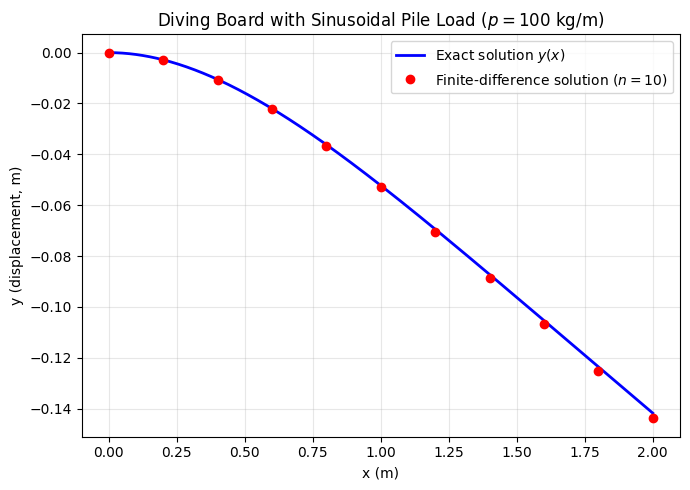

n = 10: error at x=L = 2.082780e-03, cond(A) = 1.857402e+04

       n |            h |     Error at x=L |          cond(A)
--------------------------------------------------------------
      20 | 1.000000e-01 |     5.376960e-04 |     2.822592e+05
      40 | 5.000000e-02 |     1.354649e-04 |     4.389448e+06
      80 | 2.500000e-02 |     3.393091e-05 |     6.919109e+07
     160 | 1.250000e-02 |     8.486595e-06 |     1.098637e+09
     320 | 6.250000e-03 |     2.115255e-06 |     1.751043e+10
     640 | 3.125000e-03 |     5.218474e-07 |     2.796233e+11
    1280 | 1.562500e-03 |     5.111336e-08 |     4.469659e+12
    2560 | 7.812500e-04 |     1.729164e-07 |     7.148517e+13


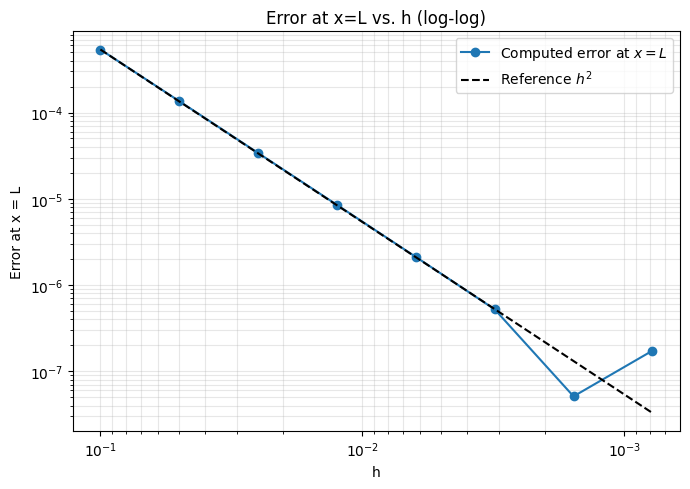

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L   = 2.0
w   = 0.30
d   = 0.03
rho = 480.0
E   = 1.3e10
g   = 9.81
p   = 100.0        # kg/m, sinusoidal pile load intensity

I  = w * d**3 / 12.0
EI = E * I
f0 = -rho * w * d * g          # beam's own weight, constant

def total_load(x):
    #f(x) + s(x): beam weight + sinusoidal pile.
    return f0 - p * g * np.sin(np.pi * x / L)

# Closed-form exact solution  y = y1 + y2  (from Problem 4)
def y_exact(x):
    y1 = f0 / (24 * EI) * x**2 * (x**2 - 4*L*x + 6*L**2)
    C  = -p * g * L / (EI * np.pi)
    y2 = C * ( (L**3 / np.pi**3) * np.sin(np.pi * x / L)
               - x**3/6 + (L/2)*x**2 - (L**2/np.pi**2)*x )
    return y1 + y2

# Structure matrix A  (Equation 2.34), unchanged by the load
def build_matrix(n):
    A = np.zeros((n, n))

    A[0, 0] = 16
    A[0, 1] = -9
    A[0, 2] = 8.0/3.0
    A[0, 3] = -1.0/4.0

    A[1, 0] = -4
    A[1, 1] = 6
    A[1, 2] = -4
    A[1, 3] = 1

    for i in range(2, n - 2):
        A[i, i-2] = 1
        A[i, i-1] = -4
        A[i, i]   = 6
        A[i, i+1] = -4
        A[i, i+2] = 1

    A[n-2, n-4] = 16.0/17.0
    A[n-2, n-3] = -60.0/17.0
    A[n-2, n-2] = 72.0/17.0
    A[n-2, n-1] = -28.0/17.0

    A[n-1, n-4] = -12.0/17.0
    A[n-1, n-3] = 96.0/17.0
    A[n-1, n-2] = -156.0/17.0
    A[n-1, n-1] = 72.0/17.0

    return A

def solve_beam(n):
    h = L / n
    A = build_matrix(n)
    x = np.array([i * h for i in range(1, n + 1)])
    b = h**4 * total_load(x) / EI

    y = np.linalg.solve(A, b)

    y_L_numeric = y[-1]
    y_L_exact   = y_exact(L)
    error_at_L  = abs(y_L_numeric - y_L_exact)

    cond_A = np.linalg.cond(A)

    return x, y, error_at_L, cond_A

# Solving for a single n, plotting numerical vs exact
n0 = 10
x0, y0, err0, cond0 = solve_beam(n0)
x0_full = np.concatenate(([0.0], x0))
y0_full = np.concatenate(([0.0], y0))

x_fine = np.linspace(0, L, 400)
y_fine = y_exact(x_fine)

plt.figure(figsize=(7, 5))
plt.plot(x_fine, y_fine, 'b-', linewidth=2, label='Exact solution $y(x)$')
plt.plot(x0_full, y0_full, 'ro', markersize=6, label=f'Finite-difference solution ($n={n0}$)')
plt.xlabel('x (m)')
plt.ylabel('y (displacement, m)')
plt.title('Diving Board with Sinusoidal Pile Load ($p=100$ kg/m)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"n = {n0}: error at x=L = {err0:.6e}, cond(A) = {cond0:.6e}\n")

# Error vs n / h table, and error vs h log-log plot
ks = range(1, 9)
ns = [10 * 2**k for k in ks]

results = []
for n in ns:
    _, _, err, cond_A = solve_beam(n)
    h = L / n
    results.append((n, h, err, cond_A))

print(f"{'n':>8} | {'h':>12} | {'Error at x=L':>16} | {'cond(A)':>16}")
print("-" * 62)
for n, h, err, cond_A in results:
    print(f"{n:>8} | {h:12.6e} | {err:16.6e} | {cond_A:16.6e}")

ns_arr    = np.array([r[0] for r in results])
hs_arr    = np.array([r[1] for r in results])
errs_arr  = np.array([r[2] for r in results])
conds_arr = np.array([r[3] for r in results])

# reference h^2 line through the first data point, for comparison
ref_h2 = errs_arr[0] * (hs_arr / hs_arr[0])**2

plt.figure(figsize=(7, 5))
plt.loglog(hs_arr, errs_arr, 'o-', label='Computed error at $x=L$')
plt.loglog(hs_arr, ref_h2, 'k--', label='Reference $h^2$')
plt.xlabel('h')
plt.ylabel('Error at x = L')
plt.title('Error at x=L vs. h (log-log)')
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

**( handwritten or typed )**

For which $n$ is the error smallest? Why does the error begin to increase with $n$ after a certain point? (Hint: look at the column with condition number values.) Is the error at $x = L$ proportional to $h^2$ as claimed above? Does the condition number come into play?

---

The error is the smallest for $n=1280$. Between $n=1280$ and $n=2560$ the trend reverses and the error begins to increase with $n$ for a similar reason as Part 3. As $n$ increases, the error can't improve things further, but the condition number keeps climbing. The error is indeed proportional to $h^2$. From $n=20$ up through $n=640$, each time $h$ is halved and the error drops by almost exactly a factor of 4. Finally, the condition number does come into play. The condition number keeps growing as the grid gets finer, which amplifies floating-point roundoff more and more each time the system is solved.